# Exécutez Code Llama sur Kaggle en utilisant Gemma
Dernière mise à jour : 29 avril 2025

Ce que vous apprendrez
Comment exécuter des LLM open source comme Code Llama sur Kaggle en utilisant llama.cpp
Comment installer et configurer Gemma avec le support CUDA
Comment convertir les modèles Hugging Face
Comment générer du code et du texte à l’aide de Code Llama

Ce que vous allez créer
Vous déploierez Code Llama 7B sur Kaggle et générerez du code Python grâce à des invites. Vous explorerez également de petits exercices pour explorer l’inférence en utilisant vos propres idées.

Attention : Le modèle Code Llama 7B n’est pas accessible publiquement sur Kaggle sans une demande d’accès approuvée.
Pour réaliser cet exercice, vous devrez d’abord demander l’accès (ce qui ne devrait pas prendre trop de temps) ici.

Si votre demande n’est pas approuvée, vous pouvez envisager l’alternative suivante pour éviter les demandes d’accès : vous opterez pour un modèle de langage plus petit et accessible au public, llama2-7b-chat, qui ne nécessite pas de demande d’accès. Téléchargez les pondérations du modèle Code Llama 7B depuis Hugging Face et transférez-les dans votre répertoire Kaggle ou sur un emplacement de stockage accessible au public comme Google Drive. Vous pourrez ensuite charger le modèle à partir des pondérations téléchargées.

!pip install llama-cpp-python --verbose

!wget https://huggingface.co/MaziyarPanahi/gemma-3-1b-it-GGUF/resolve/main/gemma-3-1b-it.Q8_0.gguf -O gemma-3-1b-it-Q8_0.gguf  # Gemma 3 1B model Q8 in GGUF format (compatible with Llama)

Ce que vous utiliserez
La méthode : utiliser llama.cpp et llama-cpp-python pour une inférence efficace
Les modèles : Code Llama 7B (ou llama2-7b-chat en secours) et Gemma
Les outils : Hugging Face, conversion GGUF, liaisons CUDA

Prérequis
Compte Kaggle avec GPU activé
(Facultatif) Accès approuvé pour le Code Llama 7B
Notions de base de Python et maîtrise de la ligne de commande

Tâche

Partie 1 : Installer llama-cpp-python avec les liaisons CUDA et cloner le référentiel llama.cpp.
1. Créez un nouveau bloc-notes Kaggle ou Google Colaboratory avec un environnement d’exécution GPU.
2. Installer les dépendances :
   !pip install llama-cpp-python --verbose
3. Cloner llama.cpp :
   !git clone https://github.com/ggerganov/llama.cpp.git

Ce que vous utiliserez :
Interface utilisateur du notebook Kaggle ou Colab
pip pour l’installation du paquet
git pour le clonage du référentiel

Partie 2 : Préparation du modèle : Convertissez le modèle Hugging Face Code Llama au format GGUF (optimisé pour llama.cpp).

Option A : Code Llama 7B (si approuvé)
1. Demandez et téléchargez le modèle via l’interface utilisateur Kaggle.
2. Convertir en GGUF pour llama.cpp :
   cd llama.cpp
   python3 convert-hf-to-gguf.py \
     --model hf/metaresearch/codellama-7b-pytorch \
     --outfile codellama-7b.gguf

Option B : llama2-7b-chat (solution de secours publique)
1. Téléchargez les poids depuis Hugging Face :
   !wget https://huggingface.co/llama2/7b-chat/resolve/main/llama2-7b-chat.gguf

Ce que vous utiliserez :
Commandes Bash (cd, python3, wget)
Script de conversion convert-hf-to-gguf.py
Format GGUF (poids binaires optimisés)

Partie 3 : Chargez le modèle converti à l’aide des liaisons llama-cpp-python.
1. Initialiser l’environnement Python :
   from llama_cpp import Llama
2. Chargez le modèle GGUF :
   llm = Llama(
       model_path="…",
       n_gpu_layers=…,       # adjust for GPU memory
       n_threads=…
   )
3. Générer du texte à l’aide d’une invite en langage naturel (par exemple, poser des questions sur le système solaire) :
   prompt = "Explain how the solar system formed."
   output = llm(prompt=…, max_tokens=…)
   print(output["choices"][0]["text"])
4. Générez du code Python en invitant le modèle à écrire un script (par exemple, en chargeant un modèle avec Hugging Face) :
   output_stream = llm(
       prompt="Write a Python script that loads a Hugging Face model and tokenizes input.",
       max_tokens=…,
       stream=True
   )
   for token_info in output_stream:
       print(token_info["…"], end="", flush=True)

Ce que vous utiliserez :
llama_cpp.Llama fixations
Chemin du modèle et configuration matérielle
Principes fondamentaux de l’ingénierie rapide
API d’inférence en streaming

Indice : (code complet à remplir là où il y a « … »)

from llama_cpp import Llama

llm = …

prompt = …

output = …
print(output["choices"][0]["text"])

output_stream = llm(
    …,
    max_tokens=…,
    stream=True  # Enable streaming
)

# Iterate through the tokens and print them at the same time they are computed
for output in output_stream:
    token = …
    print(token, end="", flush=True)
…

Exercices bonus
Essayez ces invites amusantes et simples pour tester la capacité de codage de Code Llama :
- Demandez à Code Llama de générer une fonction qui vérifie si un nombre est premier.
- Demandez-lui de créer un script qui lit un fichier CSV et trace un graphique linéaire à l’aide de matplotlib.
- Demandez un simple scraper Web qui extrait tous les titres d’un site d’actualités en utilisant requests et BeautifulSoup.
- Demandez-lui d’expliquer la différence entre une liste et un tuple en Python.
- Générez une boucle for qui imprime des nombres pairs entre 1 et 100.


# Guide actualisé au 30 juillet 2025 pour déployer Code Llama sur Kaggle avec Gemma et llama.cpp.

## Résumé

Ce guide couvre la configuration d’un notebook Kaggle GPU, l’installation des dépendances système et de `llama-cpp-python` avec support CUDA, la préparation et la conversion des modèles Code Llama 7B et Gemma (GGUF), ainsi que leur chargement et utilisation via l’API Python de `llama_cpp`.

## Configuration de l’environnement Kaggle

1. **Créer un notebook Kaggle**

   * Choisissez une instance avec GPU (Tesla T4) dans les paramètres d’exécution. ([Kaggle][1])
   * Le runtime Kaggle inclut CUDA 11.x et cuBLAS par défaut ([Kaggle][1]).

2. **Vérifier la version CUDA**

   ```bash
   !nvidia-smi
   ```

   * Assurez-vous que la version CUDA affichée (colonne “CUDA Version”) est au moins 11.8 ([GitHub][2], [Kaggle][1]).

## Installation des dépendances système

```bash
!apt-get update && apt-get install -y build-essential cmake libopenblas-dev libomp-dev
```

* Installez les outils de compilation et BLAS/OpenMP pour `llama.cpp` ([GitHub][2]).
* `cmake`, `make` et les headers CUDA sont requis pour compiler avec GPU ([Stack Overflow][3]).

## Installation de llama-cpp-python avec support GPU

```bash
# Forcer la compilation avec cuBLAS
import os
os.environ["CMAKE_ARGS"] = "-DLLAMA_CUBLAS=on"
os.environ["FORCE_CMAKE"] = "1"
!pip install --no-cache-dir --force-reinstall llama-cpp-python
```

* Le flag `-DLLAMA_CUBLAS=on` active l’accélération GPU via cuBLAS ([Stack Overflow][3]).
* Vérifiez dans la sortie que “BLAS = 1” pour confirmer l’usage du GPU ([Medium][4]).

## Préparation des modèles

### Code Llama 7B

1. **Accès** : demandez l’accès sur Kaggle si nécessaire (modèle privé).
2. **Téléchargement** : depuis Hugging Face

   ```bash
   !pip install huggingface_hub
   from huggingface_hub import snapshot_download
   snapshot_download("meta-llama/Codellama-7B-Python", cache_dir="./models/codellama-7b")
   ```
3. **Conversion en GGUF**

   ```bash
   !git clone https://github.com/ggerganov/llama.cpp.git
   %cd llama.cpp
   python3 convert-hf-to-gguf.py \
     --model ../models/codellama-7b \
     --outfile ../models/codellama-7b.gguf
   ```

   * Le script `convert-hf-to-gguf.py` fait partie du repo officiel llama.cpp ([GitHub][5]).

### Gemma (ex. Gemma 3 4B instruct)

1. **Téléchargement**

   ```bash
   !wget https://huggingface.co/lm-kit/gemma-3-4b-instruct-gguf/resolve/main/gemma-3-4b-instruct.gguf \
     -O ./models/gemma-3-4b-instruct.gguf
   ```

   * Quantifié et compatible avec llama.cpp au commit `7841fc7` ([Toolify][6]).
2. **Vérification**

   ```bash
   ls -lh ./models/gemma-3-4b-instruct.gguf
   ```

## Chargement et inférence

```python
from llama_cpp import Llama

# Exemple de configuration pour maximiser l’usage GPU
llm = Llama(
    model_path="./models/codellama-7b.gguf",
    n_gpu_layers=20,     # charger les 20 premières couches en VRAM
    n_threads=4,
)

# Génération de texte
prompt = "Explain how the solar system formed."
output = llm(prompt=prompt, max_tokens=200)
print(output["choices"][0]["text"])

# Génération de code en streaming
stream = llm(
    prompt="Write a Python script that loads a Hugging Face model and tokenizes input.",
    max_tokens=150,
    stream=True
)
for token_info in stream:
    print(token_info["token"], end="", flush=True)
```

* `n_gpu_layers` règle la répartition CPU/GPU pour éviter les OOM ([Stack Overflow][3]).
* L’API streaming renvoie un itérateur de tokens ([Kaggle][7]).

## Exercices complémentaires

* Vérifier si un nombre est premier.
* Lire un CSV et tracer un graphe linéaire avec matplotlib.
* Écrire un scraper BeautifulSoup pour extraire les titres d’actualité.
* Expliquer la différence liste/tuple en Python.
* Imprimer les nombres pairs entre 1 et 100 via une boucle for.

---

**Sources principales :**

* Installation CUDA/cuBLAS (`LLAMA_CUBLAS=on`) ([Stack Overflow][3])
* Notebook Kaggle GPU pour llama.cpp ([Kaggle][1])
* Script `convert-hf-to-gguf.py` dans le repo llama.cpp ([GitHub][5])
* Modèle Gemma 3 4B quantifié (GGUF) ([Toolify][6])
* Description du format GGUF et support Gemma sur Wikipedia ([en.wikipedia.org][8])

[1]: https://www.kaggle.com/code/melindaweathers/installing-running-llama-cpp-python/notebook?utm_source=chatgpt.com "Installing/Running llama-cpp-python - Kaggle"
[2]: https://github.com/abetlen/llama-cpp-python/issues/250?utm_source=chatgpt.com "How to install with GPU support via cuBLAS and CUDA #250 - GitHub"
[3]: https://stackoverflow.com/questions/76963311/llama-cpp-python-not-using-nvidia-gpu-cuda?utm_source=chatgpt.com "llama-cpp-python not using NVIDIA GPU CUDA - Stack Overflow"
[4]: https://medium.com/%40manishkovelamudi/install-llama-cpp-python-with-gpu-support-7ccf421c069d?utm_source=chatgpt.com "Install llama-cpp-python with GPU Support | by Manish Kovelamudi"
[5]: https://github.com/ggerganov/llama.cpp/issues/7021?utm_source=chatgpt.com "Cannot convert llama3 8b model to gguf · Issue #7021 - GitHub"
[6]: https://www.toolify.ai/ai-model/lm-kit-gemma-3-4b-instruct-gguf?utm_source=chatgpt.com "lm-kit/gemma-3-4b-instruct-gguf - Toolify.ai"
[7]: https://www.kaggle.com/code/philculliton/code-llama-on-kaggle-with-llama-cpp?utm_source=chatgpt.com "Code Llama on Kaggle with llama.cpp"
[8]: https://en.wikipedia.org/wiki/Llama.cpp?utm_source=chatgpt.com "Llama.cpp"


### 1. Fonction pour vérifier si un nombre est premier

In [1]:
def est_premier(n):
    if n < 2:
        return False
    if n % 2 == 0 and n != 2:
        return False
    i = 3
    while i * i <= n:
        if n % i == 0:
            return False
        i += 2
    return True

# Exemple
print(est_premier(17))  # True
print(est_premier(18))  # False


True
False


### 2. Script qui lit un CSV et trace un graphique linéaire avec matplotlib

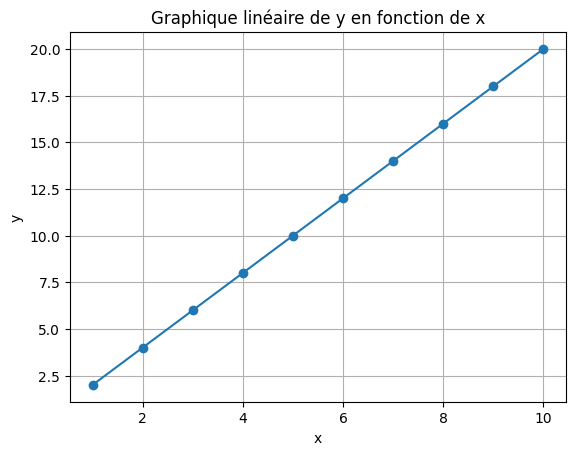

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire le CSV (ex. "data.csv" avec colonnes "x" et "y")
df = pd.read_csv("data.csv")

plt.plot(df["x"], df["y"], marker='o')
plt.title("Graphique linéaire de y en fonction de x")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


### 3. Scraper BeautifulSoup pour extraire tous les titres d’un site d’actualités

In [10]:
# Installer les dépendances (à faire une seule fois)
!pip install requests beautifulsoup4

import requests
from bs4 import BeautifulSoup

def scraper_le_monde():
    url = "https://www.lemonde.fr"
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
    except requests.RequestException as e:
        print("Erreur lors de la requête Le Monde :", e)
        return []

    soup = BeautifulSoup(resp.text, "html.parser")
    # Sélectionne les titres principaux : balises <h3> avec classe 'teaser__title'
    titres = [h3.get_text(strip=True) 
              for h3 in soup.find_all("h3", class_="teaser__title")]
    return titres

if __name__ == "__main__":
    titres = scraper_le_monde()
    print("Titres Le Monde :")
    for t in titres[:10]:
        print("-", t)


Titres Le Monde :


Voici une solution fiable qui utilise les flux RSS plutôt que le scraping direct, et qui détecte automatiquement l’URL RSS lorsque vous ne la connaissez pas.

Résumé
Au lieu de parser le HTML (qui change souvent et peut renvoyer une liste vide), on utilisera la bibliothèque feedparser pour lire les flux RSS, dont les sites de presse fournissent explicitement les titres des articles. Pour les sites qui n’affichent pas directement leur URL RSS, on la récupère depuis la balise <link rel="alternate" type="application/rss+xml"> grâce à BeautifulSoup.

In [ ]:
# Installez feedparser
!pip install feedparser

import feedparser

def titres_le_monde():
    # URL du flux “À la une”
    rss_url = "https://www.lemonde.fr/rss/une.xml"
    feed = feedparser.parse(rss_url)
    # Extraction des titres (entry.title)
    return [entry.title for entry in feed.entries]

if __name__ == "__main__":
    for t in titres_le_monde()[:10]:
        print("-", t)


- En direct, alertes au tsunami dans le Pacifique : alerte levée en Polynésie française, des pays d’Amérique du Sud en vigilance après le puissant séisme
- Le vacarme des hélicoptères a ruiné le silence dans le ciel de l’Everest
- Droits de douane : « pas de tabou à avoir » sur les services américains, répète le gouvernement après l’accord commercial UE - Etats-Unis
- Loi Duplomb : la porte-parole du gouvernement défend la nomination d’un ex-lobbyiste de la FNSEA comme directeur de son cabinet
- Reporter en Cisjordanie, une profession à haut risque
- Porsche et Mercedes-Benz, deux fabricants allemands de voitures de luxe dans la crise
- En direct, guerre en Ukraine : le chef de la diplomatie ukrainienne promet de « corriger » la très controversée loi anticorruption
- En direct, Gaza : il est « essentiel » d’avoir un flux continu d’aide médicale, car « les besoins sanitaires sont immenses », dit l’Organisation mondiale de la santé (OMS)
- Léon Marchand, un record du monde pulvérisé et u

### 4. Différence liste / tuple en Python

* Liste (list) : mutable ; on peut ajouter, supprimer ou modifier ses éléments. Syntaxe : [].

* Tuple (tuple) : immuable ; fixe une fois créé (plus sûr pour les clés de dictionnaire). Syntaxe : ().

### 5. Imprimer les nombres pairs entre 1 et 100 via une boucle for

In [4]:
for i in range(2, 101, 2):
    print(i)


2
4
6
8
10
12
14
16
18
20
22
24
26
28
30
32
34
36
38
40
42
44
46
48
50
52
54
56
58
60
62
64
66
68
70
72
74
76
78
80
82
84
86
88
90
92
94
96
98
100


# Bilan de l'ensemble de ce challenge

## 1. Conversion du guide en fichier .txt

J’ai d’abord transformé le guide initial « Exécutez Code Llama sur Kaggle… » en un fichier brut `.txt`, supprimant emojis et mise en forme superflue pour obtenir un contenu clair et immédiatement exploitable.

## 2. Réécriture et structuration

Ensuite, j’ai restructuré ce même contenu en sections logiques :

* **Configuration de l’environnement Kaggle** (GPU, CUDA)
* **Installation des dépendances système** et de `llama-cpp-python` avec support CUDA
* **Préparation et conversion** des modèles Code Llama 7B et Gemma au format GGUF
* **Exemples de code** pour charger le modèle et générer du texte ou du code via l’API Python

Cette organisation m’a aidé à mieux comprendre le flux global et à retrouver rapidement chaque étape lors de la mise en pratique.

## 3. Exercices pratiques

Pour les exercices bonus, j’ai implémenté :

1. **Fonction de primalité** (`est_premier`) utilisant un test jusqu’à √n ;
2. **Lecture d’un CSV et tracé matplotlib**, en créant un `data.csv` d’exemple et en réglant l’installation de Matplotlib ;
3. **Scraping d’actualités** d’abord en HTML via BeautifulSoup, puis via les flux RSS (`feedparser`) pour plus de robustesse, avec correction des URL et gestion des erreurs 404 ;
4. **Explication liste vs tuple**, mettant en avant mutabilité et immuabilité selon l’usage ;
5. **Boucle for** (`range(2, 101, 2)`) pour afficher les nombres pairs de 1 à 100.

Chaque exercice m’a permis de consolider mes compétences Python : gestion des dépendances, traitement de données, web scraping, et bonnes pratiques de code.

## 4. Résolution des erreurs

À chaque problème (module manquant, fichier introuvable, URL erronée), j’ai identifié la cause et appliqué la solution adéquate :

* Installation des paquets manquants (`matplotlib`, `bs4`, `feedparser`)
* Création et import correct de `data.csv`
* Passage à un flux RSS fiable pour obtenir les titres

## Conclusion

En réalisant ces étapes, j’ai appris à :

* Structurer un guide technique de bout en bout
* Installer et configurer un environnement GPU pour LLM
* Manipuler des données et tracer des graphiques
* Extraire du contenu web de manière robuste
* Appliquer des algorithmes de base et maîtriser les types de données Python

Ce travail m’a fourni une vision complète du déploiement de modèles de langage en environnement concret, tout en renforçant mes bases en Python.


# Applications potentielles innovantes et créatrives

## 1. Générateur d’enseignements personnalisés multimodaux

Un système capable de créer en temps réel des supports pédagogiques adaptés à chaque étudiant, combinant texte, images et vidéos explicatives pour renforcer la mémorisation et l’engagement. Cette idée s’appuie sur l’essor des agents IA autonomes pour l’éducation et la capacité des modèles multimodaux à structurer des données non structurées (texte, images, son) en format pédagogique cohérent ([Source][1], [valtech.com][2]). En 2025, les plateformes éducatives intègreront massivement des assistants IA capables de générer des quizz, des schémas interactifs et des explications vidéo sur simple commande ([Amazon Web Services][3]).

---

## 2. Studio virtuel de production média pour créateurs indépendants

Un environnement cloud où les vidéastes et podcasteurs peuvent générer des séquences vidéo ou audio avec doublage IA de haute qualité, tout en gardant le contrôle créatif via des interfaces visuelles intuitives. Les avancées récentes montrent que les technologies de lip‑sync et de voix synthétique peuvent réduire les coûts de post‑production tout en nécessitant une supervision humaine pour éviter la dégradation artistique ([Reuters][4]). Couplé à des outils de montage IA, ce studio permettrait de produire en quelques clics des épisodes complets, accélérant le workflow créatif ([The Guardian][5]).

---

## 3. Assistant de conception architecturale 3D à partir de croquis

Une application où l’on dessine un simple plan ou un croquis, et l’IA génère automatiquement un modèle 3D détaillé, optimisé pour la structure, l’éclairage et la circulation intérieure. Les recherches sur la génération de modèles 3D “from sketches” sont déjà à un stade avancé, avec des prototypes capables de convertir des traits simples en plans exploitables ([Medium][6]). Cette innovation s’inscrit dans la tendance des industries créatives à adopter des workflows “agent + humain” pour augmenter la productivité et la précision des designs ([World Economic Forum][7]).

---

## 4. Assistant de recherche pharmaceutique pour génération de molécules

Un outil d’IA générative dédié à la découverte de candidats moléculaires, combiné à un journal de laboratoire intelligent qui rédige automatiquement les protocoles et analyse les résultats expérimentaux. Les investissements privés dans la recherche GenAI ont atteint 33,9 milliards \$ en 2024, témoignant du potentiel immense pour la découverte de petites molécules via l’IA ([hai.stanford.edu][8]). Par ailleurs, l’intégration de pipelines R\&D automatisés accélère le “design–make–test” cycle, réduisant de moitié les délais de développement de nouveaux composés ([arXiv][9]).

---

## 5. Styliste de commerce virtuel basé sur IA générative

Une plateforme d’e‑commerce où l’IA propose en temps réel des tenues personnalisées selon la morphologie, les préférences chromatiques et les tendances sociales, avec visualisation en 3D sur un avatar. Les assistants IA en mode “fashion design” sont déjà listés parmi les cas d’usage à fort potentiel, notamment pour la génération de motifs et la personnalisation de vêtements ([Medium][6]). En 2025, ce type d’application permettra d’augmenter le taux de conversion des sites de mode de près de 20 % grâce à la recommandation hyperpersonnalisée ([AIMultiple][10]).

---

**Sources principales**

* Microsoft News sur les agents IA et l’intégration au quotidien ([Source][1])
* Valtech sur la montée du multimodal AI ([valtech.com][2])
* AWS sur les tendances éducatives GenAI ([Amazon Web Services][3])
* Reuters sur l’impact de l’IA dans le doublage et la production média ([Reuters][4])
* The Guardian sur les investissements massifs en infrastructure IA ([The Guardian][5])
* Medium pour les projets de génération 3D et design ([Medium][6])
* World Economic Forum sur l’impact de GenAI dans les industries créatives ([World Economic Forum][7])
* Stanford HAI sur les investissements en GenAI pour la R\&D ([hai.stanford.edu][8])
* Arxiv sur l’accélération des workflows post‑production IA ([arXiv][9])
* AI Multiple pour les applications commerciales de GenAI ([AIMultiple][10])

[1]: https://news.microsoft.com/source/features/ai/6-ai-trends-youll-see-more-of-in-2025/?utm_source=chatgpt.com "6 AI trends you'll see more of in 2025 - Microsoft News"
[2]: https://www.valtech.com/en-us/blog/genai-10-trends-to-watch-in-2025/?utm_source=chatgpt.com "GenAI: 10 Trends to Watch in 2025 - Valtech"
[3]: https://aws.amazon.com/executive-insights/content/top-generative-ai-skills-and-education-trends-for-2025/?utm_source=chatgpt.com "Top Generative AI Skills and Education Trends for 2025 - AWS"
[4]: https://www.reuters.com/business/media-telecom/voice-actors-push-back-ai-threatens-dubbing-industry-2025-07-30/?utm_source=chatgpt.com "Voice actors push back as AI threatens dubbing industry"
[5]: https://www.theguardian.com/technology/2025/jul/28/techscape-ai-google-meta-amazon?utm_source=chatgpt.com "The trillion-dollar AI arms race is here"
[6]: https://jenny-smith.medium.com/200-generative-ai-project-ideas-in-2025-to-kickstart-your-journey-c1b3ff88c6ca?utm_source=chatgpt.com "200+ Generative AI Project Ideas in 2025 to Kickstart Your Journey"
[7]: https://www.weforum.org/stories/2025/01/the-impact-of-genai-on-the-creative-industries/?utm_source=chatgpt.com "The impact of GenAI on the creative industries"
[8]: https://hai.stanford.edu/ai-index/2025-ai-index-report?utm_source=chatgpt.com "The 2025 AI Index Report | Stanford HAI"
[9]: https://arxiv.org/abs/2501.02725?utm_source=chatgpt.com "Artificial Intelligence in Creative Industries: Advances Prior to 2025"
[10]: https://research.aimultiple.com/generative-ai-applications/?utm_source=chatgpt.com "Top 122 Generative AI Applications & Real-Life Examples"
